In [1]:
import torch
from vllm import LLM, SamplingParams

llm = LLM(
    model="Qwen/Qwen3-0.6B",
    task="generate",
)

/home/ubuntu/ping/summer-offsite/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO 12-04 12:29:49 [utils.py:253] non-default args: {'task': 'generate', 'seed': None, 'disable_log_stats': True}
WARNING 12-04 12:29:49 [arg_utils.py:1175] `seed=None` is equivalent to `seed=0` in V1 Engine. You will no longer be allowed to pass `None` in v0.13.
INFO 12-04 12:29:50 [model.py:637] Resolved architecture: Qwen3ForCausalLM
INFO 12-04 12:29:50 [model.py:1750] Using max model len 40960


2025-12-04 12:29:50,567	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


INFO 12-04 12:29:50 [scheduler.py:228] Chunked prefill is enabled with max_num_batched_tokens=8192.
(EngineCore_DP0 pid=8641) INFO 12-04 12:29:51 [core.py:93] Initializing a V1 LLM engine (v0.12.0) with config: model='Qwen/Qwen3-0.6B', speculative_config=None, tokenizer='Qwen/Qwen3-0.6B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=40960, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_fallback=False, disable_any_whitespace=False, disable_additional_properties=False, reasoning_parser='', reasoning_parser_plugin='', enable_in_reasoning=False), observability_config=ObservabilityConfig(show_hidden_metrics_for_version=None, otlp_traces_endpoint

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  5.63it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  5.57it/s]
(EngineCore_DP0 pid=8641) 


(EngineCore_DP0 pid=8641) INFO 12-04 12:29:54 [default_loader.py:308] Loading weights took 0.22 seconds
(EngineCore_DP0 pid=8641) INFO 12-04 12:29:54 [gpu_model_runner.py:3549] Model loading took 1.1201 GiB memory and 0.975006 seconds
(EngineCore_DP0 pid=8641) INFO 12-04 12:30:00 [backends.py:655] Using cache directory: /home/ubuntu/.cache/vllm/torch_compile_cache/88ebe42056/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=8641) INFO 12-04 12:30:00 [backends.py:715] Dynamo bytecode transform time: 5.84 s
(EngineCore_DP0 pid=8641) INFO 12-04 12:30:03 [backends.py:216] Directly load the compiled graph(s) for dynamic shape from the cache, took 2.498 s
(EngineCore_DP0 pid=8641) INFO 12-04 12:30:04 [monitor.py:34] torch.compile takes 8.33 s in total
(EngineCore_DP0 pid=8641) INFO 12-04 12:30:05 [gpu_worker.py:359] Available KV cache memory: 37.40 GiB
(EngineCore_DP0 pid=8641) INFO 12-04 12:30:06 [kv_cache_utils.py:1286] GPU KV cache size: 350,096 tokens
(EngineCore_DP0 pid=864

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:01<00:00, 35.26it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:00<00:00, 35.96it/s]


(EngineCore_DP0 pid=8641) INFO 12-04 12:30:09 [gpu_model_runner.py:4466] Graph capturing finished in 3 secs, took 0.45 GiB
(EngineCore_DP0 pid=8641) INFO 12-04 12:30:09 [core.py:254] init engine (profile, create kv cache, warmup model) took 14.59 seconds
INFO 12-04 12:30:10 [llm.py:343] Supported tasks: ['generate']


In [5]:
prompts = [
    "The future of AI is",
    "In a distant galaxy far away",
]

sampling_params = SamplingParams(
    temperature=0.0,  # greedy
    max_tokens=1,
    logprobs=30
)

outputs = llm.generate(prompts, sampling_params)

print("Generated outputs len:", len(outputs))
for i, output in enumerate(outputs):
    print(f"Output {i}:", output)   
    print("Outputs:", output.outputs)
    print("Outputs type:", type(output.outputs))
    print("Outputs len:", len(output.outputs))
    print("Logprobs:", output.outputs[0].logprobs[0])
    print("Logprobs len:", len(output.outputs[0].logprobs))
    if 11 in output.outputs[0].logprobs[0]:
        print("Logprobs for token id 11:", output.outputs[0].logprobs[0][11])
        print("id 11 rank:", output.outputs[0].logprobs[0][11].rank)
    else:
        print("Token id 11 not in logprobs.")
    
# # 取得最後一個 token 的 logits

# # 這時 GPUModelRunner.execute_model 已經跑完，logit_spy.LAST_LOGITS 應該被寫過
# import vllm.logit_spy as logit_spy   # 再 import 一次確保是同一個模組
# final_logits = logit_spy.LAST_LOGITS

# print("LAST_LOGITS type:", type(final_logits))
# print("LAST_LOGITS shape:", final_logits.shape)  # -> [batch_size, vocab_size]

# # 拿每個 prompt 最可能的「下一個 token」
# next_token_ids = torch.argmax(final_logits, dim=-1)
# print("next_token_ids:", next_token_ids.tolist())

Processed prompts: 100%|██████████| 2/2 [00:00<00:00, 169.85it/s, est. speed input: 982.13 toks/s, output: 178.36 toks/s]

Generated outputs len: 2
Output 0: RequestOutput(request_id=6, prompt='The future of AI is', prompt_token_ids=[785, 3853, 315, 15235, 374], encoder_prompt=None, encoder_prompt_token_ids=None, prompt_logprobs=None, outputs=[CompletionOutput(index=0, text=' not', token_ids=[537], cumulative_logprob=-2.29032564163208, logprobs=[{537: Logprob(logprob=-2.29032564163208, rank=1, decoded_token=' not'), 264: Logprob(logprob=-2.47782564163208, rank=2, decoded_token=' a'), 25383: Logprob(logprob=-2.54032564163208, rank=3, decoded_token=' promising'), 1660: Logprob(logprob=-2.97782564163208, rank=4, decoded_token=' being'), 304: Logprob(logprob=-3.29032564163208, rank=5, decoded_token=' in'), 53846: Logprob(logprob=-3.79032564163208, rank=6, decoded_token=' poised'), 1588: Logprob(logprob=-3.79032564163208, rank=7, decoded_token=' here'), 389: Logprob(logprob=-3.97782564163208, rank=8, decoded_token=' on'), 738: Logprob(logprob=-4.10282564163208, rank=9, decoded_token=' set'), 2176: Logprob(logpr

In [4]:
import tqdm

# Outputs will be deterministic regardless of batch size
outputs_list = [[] for _ in range(3)]
for t_id in tqdm.tqdm(range(1, 1000)):
    outputs = llm.generate(prompts, sampling_params, use_tqdm=False)

    for i, output in enumerate(outputs):
        prompt = output.prompt
        generated_text = output.outputs[0].text
        # print(f"Prompt: {prompt!r}")
        # print(f"Generated: {generated_text!r}\n")
        outputs_list[i].append(generated_text)

for i, outputs in enumerate(outputs_list):
    assert all(output == outputs[0] for output in outputs), f"Outputs for prompt {i} differ across runs."

 26%|██▋       | 264/999 [00:04<00:13, 54.45it/s]


KeyboardInterrupt: 

In [3]:
for i, outputs in enumerate(outputs_list):
    assert all(output == outputs[0] for output in outputs), f"Outputs for prompt {i} differ across runs."

In [ ]:
sampling_params = SamplingParams(
    temperature=0,
    max_tokens=1,
    detokenize=False
)
from vllm.sampling_params import SamplingParams, RequestOutputKind
import torch

sampling_params = SamplingParams(
    temperature=0.0,
    max_tokens=1,
    output_kind=RequestOutputKind.CUMULATIVE, # CUMULATIVE FINAL_ONLY
    detokenize=True,
    logprobs=10, # -1
    logits_processors=[logits_spy]
)

outputs = llm.generate(prompts, sampling_params, use_tqdm=False)

print(outputs[0].outputs)

ValueError: vLLM V1 does not support per request user provided logits processors.

In [6]:
# read the rank list from rank_list.txt
# file_name = "rank_list_text8_Qwen3-8.txt"
file_name = "rank_list_code_Qwen3-8.txt"
with open(file_name, "r") as f:
    rank_list = [int(line.strip()) for line in f.readlines()]

print(f"len of rank list: {len(rank_list)}")
print(f"max rank: {max(rank_list)}")

# how many unique ranks are there
unique_ranks = set(rank_list)
print(f"number of unique ranks: {len(unique_ranks)}")
# percentage of rank lower than n
n = 256
lower_than = sum(1 for r in rank_list if r < n)
print(f"percentage of rank lower than {n}: {lower_than / len(rank_list) * 100:.2f}%")

# bitpack encoding depend on max rank
# max_rank = max(rank_list) if rank_list else 0
# num_bits = max_rank.bit_length()

# print(f"max_rank = {max_rank}, num_bits = {num_bits}")

# bit_chunks = [format(rank, f'0{num_bits}b') for rank in rank_list]
# bit_string = "".join(bit_chunks)
# print(f"length of bit string: {len(bit_string)}")

# # decoding the bit string back to rank list
# decoded_rank_list = []
# for i in range(0, len(bit_string), num_bits):
#     bits = bit_string[i:i+num_bits]
#     if not bits:
#         continue
#     rank = int(bits, 2)
#     decoded_rank_list.append(rank)

# assert decoded_rank_list == rank_list, "Decoded rank list does not match original"

len of rank list: 499872
max rank: 19665
number of unique ranks: 3797
percentage of rank lower than 256: 97.28%


In [7]:
# for rank 0-10 print the percentage of each rank in the rank list
for r in range(20):
    count = sum(1 for rank in rank_list if rank == r)
    percentage = count / len(rank_list) * 100
    print(f"Rank {r} :\t{percentage:.4f}%, \tcount: {count}")

Rank 0 :	72.4207%, 	count: 362011
Rank 1 :	8.3681%, 	count: 41830
Rank 2 :	3.2826%, 	count: 16409
Rank 3 :	1.8413%, 	count: 9204
Rank 4 :	1.2505%, 	count: 6251
Rank 5 :	0.9254%, 	count: 4626
Rank 6 :	0.7004%, 	count: 3501
Rank 7 :	0.5573%, 	count: 2786
Rank 8 :	0.4567%, 	count: 2283
Rank 9 :	0.3897%, 	count: 1948
Rank 10 :	0.3375%, 	count: 1687
Rank 11 :	0.2907%, 	count: 1453
Rank 12 :	0.2685%, 	count: 1342
Rank 13 :	0.2413%, 	count: 1206
Rank 14 :	0.2041%, 	count: 1020
Rank 15 :	0.1940%, 	count: 970
Rank 16 :	0.1712%, 	count: 856
Rank 17 :	0.1638%, 	count: 819
Rank 18 :	0.1494%, 	count: 747
Rank 19 :	0.1352%, 	count: 676


/tmp/ipykernel_36134/3993379739.py:10: RuntimeWarning: divide by zero encountered in log2
  np.floor(np.log2(ranks)).astype(int) + 1,
/tmp/ipykernel_36134/3993379739.py:10: RuntimeWarning: invalid value encountered in cast
  np.floor(np.log2(ranks)).astype(int) + 1,


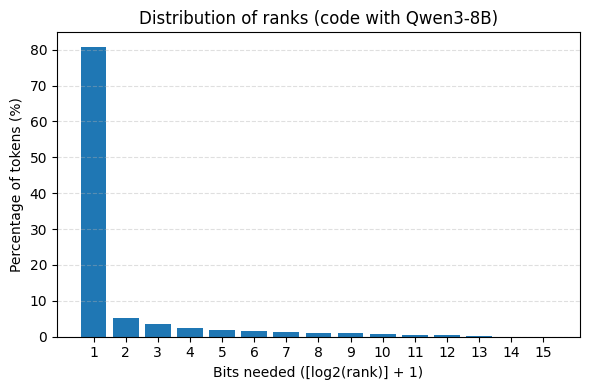

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# rank_list is your list/array of integer ranks
ranks = np.asarray(rank_list, dtype=np.int64)

# bits needed per rank (1 bit for 0, else floor(log2(r)) + 1)
bits_per_rank = np.where(
    ranks > 0,
    np.floor(np.log2(ranks)).astype(int) + 1,
    1,
)

max_bits = bits_per_rank.max()
counts = np.bincount(bits_per_rank, minlength=max_bits + 1)

bit_values = np.arange(1, max_bits + 1)
bit_counts = counts[1:max_bits + 1]

# convert to percentage
total = bit_counts.sum()
bit_percent = bit_counts / total * 100.0

plt.figure(figsize=(6, 4))
plt.bar(bit_values, bit_percent, width=0.8)

plt.xlabel("Bits needed ([log2(rank)] + 1)")
plt.ylabel("Percentage of tokens (%)")
plt.title("Distribution of ranks (code with Qwen3-8B)")
plt.xticks(bit_values)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

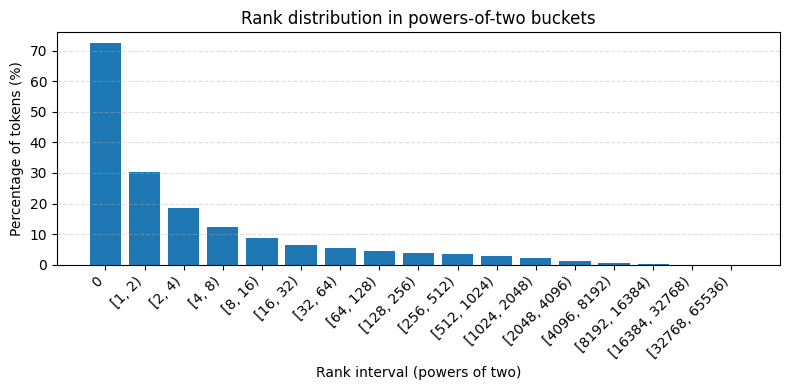

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# rank_list is your list/array of integer ranks
ranks = np.asarray(rank_list, dtype=np.int64)
ranks = ranks[ranks >= 0]
zero_count = np.sum(ranks == 0)
ranks = ranks[ranks > 0]

if ranks.size == 0:
    raise ValueError("All ranks are 0 or negative; nothing to plot.")

max_rank = ranks.max()

max_pow = int(np.ceil(np.log2(max_rank)))
# bin edges: 1, 2, 4, 8, ..., 2^(max_pow+1)
bin_edges = 2 ** np.arange(0, max_pow + 2, dtype=np.int64)


#histogram
hist, edges = np.histogram(ranks, bins=bin_edges)
total_nonzero = hist.sum()
percent = hist / total_nonzero * 100.0

labels = [f"[{int(edges[i])}, {int(edges[i+1])})" for i in range(len(edges) - 1)]
if zero_count > 0:
    zero_percent = zero_count / (zero_count + total_nonzero) * 100.0
    percent = np.concatenate([[zero_percent], percent])
    labels = ["0"] + labels

x = np.arange(len(percent))

plt.figure(figsize=(8, 4))
plt.bar(x, percent)

plt.ylabel("Percentage of tokens (%)")
plt.xlabel("Rank interval (powers of two)")
plt.title("Rank distribution in powers-of-two buckets")

if len(labels) > 20:
    step = 2
    plt.xticks(x[::step], labels[::step], rotation=45, ha="right")
else:
    plt.xticks(x, labels, rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

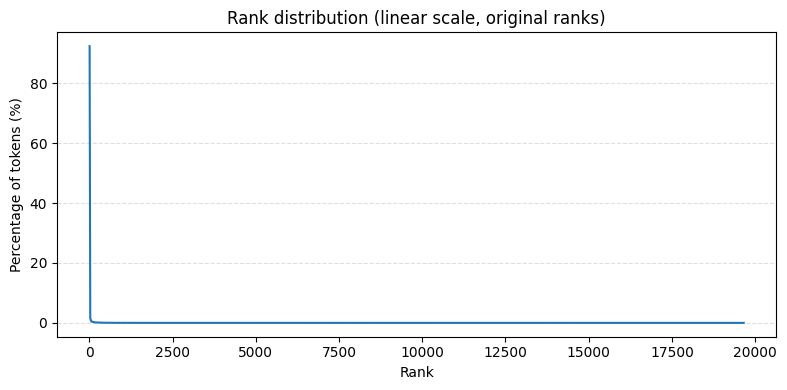

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# rank_list is your list/array of integer ranks
ranks = np.asarray(rank_list, dtype=np.int64)

min_rank = int(ranks.min())
max_rank = int(ranks.max())

# choose a reasonable number of bins (linear in rank space)
# you can tune n_bins; 100 is a typical choice
n_bins = min(max_rank - min_rank + 1, 1000)
hist, edges = np.histogram(ranks, bins=n_bins, range=(min_rank, max_rank + 1))

total = hist.sum() if hist.sum() > 0 else 1
percent = hist / total * 100.0

# bin centers for line plot
centers = 0.5 * (edges[:-1] + edges[1:])

plt.figure(figsize=(8, 4))
plt.plot(centers, percent)
plt.fill_between(centers, percent, alpha=0.3)

plt.xlabel("Rank")
plt.ylabel("Percentage of tokens (%)")
plt.title("Rank distribution (linear scale, original ranks)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

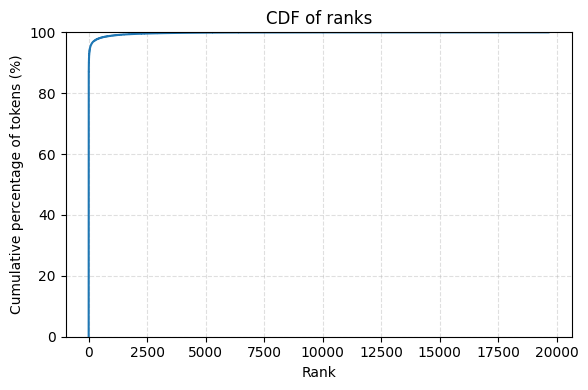

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# rank_list is your list/array of integer ranks
ranks = np.asarray(rank_list, dtype=np.int64)

# ignore negative ranks just in case
ranks = ranks[ranks >= 0]

# sort all ranks for empirical CDF
ranks_sorted = np.sort(ranks)

# CDF: for the k-th smallest rank, proportion of tokens ≤ that rank
n = len(ranks_sorted)
cdf_percent = np.arange(1, n + 1) / n * 100.0

plt.figure(figsize=(6, 4))
plt.step(ranks_sorted, cdf_percent, where="post")

plt.xlabel("Rank")
plt.ylabel("Cumulative percentage of tokens (%)")
plt.title("CDF of ranks")

plt.ylim(0, 100)
# plt.xscale("log")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

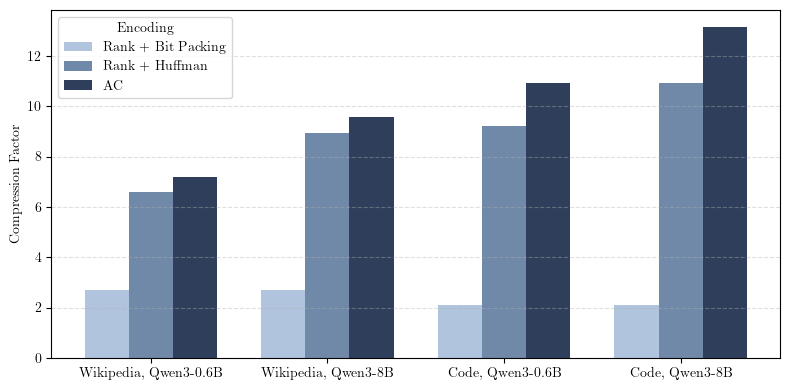

In [35]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
})

with open("compression_results_rank.json", "r") as f:
    results = json.load(f)

def get_encoded_size_bytes(dataset, model, enc):
    prefix = f"{dataset}:{model}"
    enc_tag = f"enc={enc}"
    for key, entry in results.items():
        if key.startswith(prefix) and enc_tag in key:
            return entry["compression"]["compression_factor"]
    raise KeyError(f"Not found: {dataset}, {model}, {enc}")


groups = [
    ("Wiki", "text8", "Qwen/Qwen3-0.6B"),
    ("Wiki", "text8", "Qwen/Qwen3-8B"),
    ("Code", "combined_100mb.py", "Qwen/Qwen3-0.6B"),
    ("Code", "combined_100mb.py", "Qwen/Qwen3-8B"),
]
group_labels = [
    "Wikipedia, Qwen3-0.6B",
    "Wikipedia, Qwen3-8B",
    "Code, Qwen3-0.6B",
    "Code, Qwen3-8B",
]

methods = ["bitpacked", "huffman", "AC"]
method_colors = {
    "bitpacked": "#b0c4de",  # light steel blue
    "huffman":  "#7089a9",   # medium blue-grey
    "AC":       "#2f3f5b",   # dark blue-grey
}

sizes_mib = np.zeros((len(groups), len(methods)), dtype=float)

for gi, (ds_name, ds_file, model) in enumerate(groups):
    for mi, enc in enumerate(methods):
        size_bytes = get_encoded_size_bytes(ds_file, model, enc)
        sizes_mib[gi, mi] = size_bytes

x = np.arange(len(groups))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 4))

for mi, enc in enumerate(methods):
    offset = (mi - 1) * width
    if enc == "AC":
        label_value = f"AC"
    elif enc == "huffman":
        label_value = f"Rank + Huffman"
    else:
        label_value = f"Rank + Bit Packing"
    ax.bar(x + offset, sizes_mib[:, mi], width, label=label_value, color=method_colors[enc])

ax.set_ylabel("Compression Factor")
ax.set_xticks(x)
ax.set_xticklabels(group_labels, rotation=0)
# ax.set_title("Compression Factor for AC / Bit Packing / Huffman\n(Qwen3-0.6B vs Qwen3-8B, Wikipedia vs Code)")
ax.legend(title="Encoding")

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("figures/compression_factors_encoding.pdf")
plt.show()

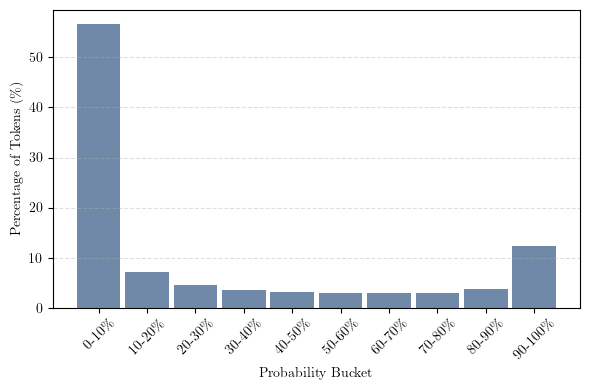

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
})

file_name = "probs_list_text_0.6.txt"
# file_name = "probs_list_code_0.6.txt"
with open(file_name, "r") as f:
    prob_list = [float(line.strip()) for line in f.readlines()]

probs = np.asarray(prob_list, dtype=float)

bins = np.linspace(0.0, 1.0, 11)  

counts, edges = np.histogram(probs, bins=bins)

total = counts.sum()
percent = counts / total * 100.0

centers = 0.5 * (edges[:-1] + edges[1:])

plt.figure(figsize=(6, 4))
plt.bar(centers, percent, width=0.09,color="#7089a9") 

bin_labels = [rf"{int(edges[i]*100)}-{int(edges[i+1]*100)}\%" for i in range(len(edges)-1)]
plt.xticks(centers, bin_labels, rotation=45, ha="center")

plt.xlabel("Probability Bucket")
plt.ylabel(r"Percentage of Tokens (\%)")
# plt.title("Distribution of correct-token probabilities (code with Qwen3-8B)")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("figures/probability_distribution_wiki_0.6.pdf")
plt.show()

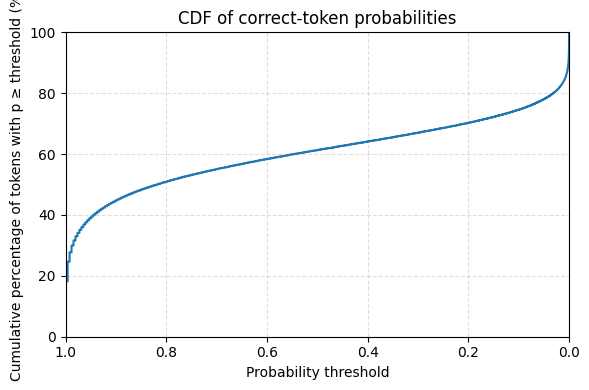

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Read probabilities from file (one prob per line)
file_name = "probs_list.txt"
with open(file_name, "r") as f:
    prob_list = [float(line.strip()) for line in f.readlines()]

probs = np.asarray(prob_list, dtype=float)

# Remove any out-of-range noise just in case
probs = probs[(probs >= 0.0) & (probs <= 1.0)]

# Sort in *descending* order so we go from 1.0 -> 0.0
probs_sorted = np.sort(probs)[::-1]
n = len(probs_sorted)

# Descending CDF: for each threshold (each prob value),
# fraction of tokens with prob >= that value
cdf_desc = np.arange(1, n + 1) / n * 100.0

plt.figure(figsize=(6, 4))
plt.step(probs_sorted, cdf_desc, where="post")

# Make x-axis clearly show 1.0 → 0.0
plt.xlim(0.0, 1.0)
plt.gca().invert_xaxis()

plt.xlabel("Probability threshold")
plt.ylabel("Cumulative percentage of tokens with p ≥ threshold (%)")
plt.title("CDF of correct-token probabilities")

plt.ylim(0, 100)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

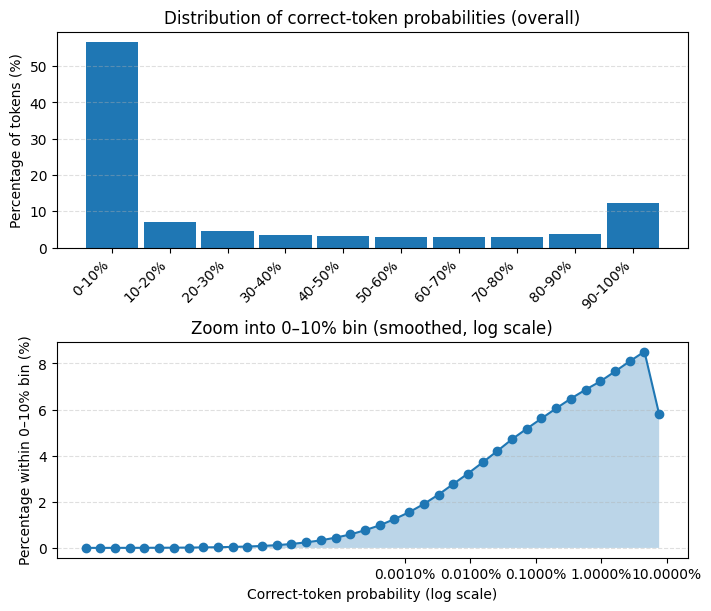

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 讀取機率
file_name = "probs_list.txt"
with open(file_name, "r") as f:
    prob_list = [float(line.strip()) for line in f.readlines()]

probs = np.asarray(prob_list, dtype=float)

# =======================
# 上圖：0–10%, 10–20%, ...
# =======================
bins = np.linspace(0.0, 1.0, 11)  # 0,0.1,...,1.0
counts, edges = np.histogram(probs, bins=bins)

total = counts.sum()
percent = counts / total * 100.0
centers = 0.5 * (edges[:-1] + edges[1:])

# =======================
# 下圖：只看 (0, 10%]，x 用 log
# =======================
low_mask = (probs > 0.0) & (probs <= 0.1)   # 去掉 0，保留 (0, 0.1]
low_probs = probs[low_mask]

if low_probs.size == 0:
    print("No probs in (0, 10%].")
else:
    min_p = low_probs.min()
    eps = 1e-10
    min_p = max(min_p, eps)

    n_bins = 40  # 可以適當多一點，之後再平滑
    log_bins = np.logspace(np.log10(min_p), np.log10(0.1), num=n_bins+1)
    fine_counts, fine_edges = np.histogram(low_probs, bins=log_bins)

    fine_total = fine_counts.sum() if fine_counts.sum() > 0 else 1
    fine_percent = fine_counts / fine_total * 100.0
    fine_centers = np.sqrt(fine_edges[:-1] * fine_edges[1:])  # 幾何中心

    # ---- smoothing: moving average on fine_percent ----
    window = 3  # 平滑窗口大小，可以試 5
    kernel = np.ones(window) / window
    fine_percent_smooth = np.convolve(fine_percent, kernel, mode="same")

    # =======================
    # 畫在同一張 figure
    # =======================
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), constrained_layout=True)

    # 上：整體 bucket
    ax1.bar(centers, percent, width=0.09)
    bin_labels = [f"{int(edges[i]*100)}-{int(edges[i+1]*100)}%" for i in range(len(edges)-1)]
    ax1.set_xticks(centers)
    ax1.set_xticklabels(bin_labels, rotation=45, ha="right")
    ax1.set_ylabel("Percentage of tokens (%)")
    ax1.set_title("Distribution of correct-token probabilities (overall)")
    ax1.grid(axis="y", linestyle="--", alpha=0.4)

    # 下：0–10%，log + smooth line
    ax2.plot(fine_centers, fine_percent_smooth, marker="o")
    ax2.fill_between(fine_centers, fine_percent_smooth, alpha=0.3)  # 想要更乾淨可以刪掉這行
    ax2.set_xscale("log")

    xticks = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
    xticks = [t for t in xticks if min_p <= t <= 0.1]
    ax2.set_xticks(xticks)
    ax2.set_xticklabels([f"{t*100:.4f}%" for t in xticks])

    ax2.set_xlabel("Correct-token probability (log scale)")
    ax2.set_ylabel("Percentage within 0–10% bin (%)")
    ax2.set_title("Zoom into 0–10% bin (smoothed, log scale)")
    ax2.grid(axis="y", linestyle="--", alpha=0.4)

    plt.show()

min prob (after eps): 1.2168044349891716e-13


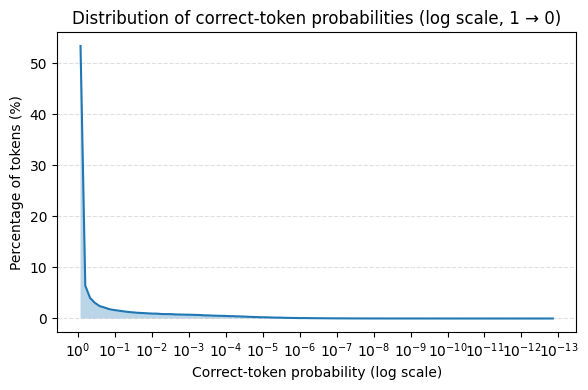

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# read probs
file_name = "probs_list.txt"
with open(file_name, "r") as f:
    prob_list = [float(line.strip()) for line in f.readlines()]

probs = np.asarray(prob_list, dtype=float)

# keep only (0, 1] to avoid log(0)
probs = probs[(probs > 0.0) & (probs <= 1.0)]
if probs.size == 0:
    raise ValueError("No probabilities in (0, 1].")

# log-spaced bins from min_p to 1.0
eps = 1e-16
min_p = max(probs.min(), eps)
print(f"min prob (after eps): {min_p}")

n_bins = 100  # adjust if you want smoother / more detailed
bins = np.logspace(np.log10(min_p), np.log10(1.0), num=n_bins + 1)

counts, edges = np.histogram(probs, bins=bins)
total = counts.sum() if counts.sum() > 0 else 1
percent = counts / total * 100.0

# geometric centers for plotting on log scale
centers = np.sqrt(edges[:-1] * edges[1:])

plt.figure(figsize=(6, 4))
plt.plot(centers, percent)
plt.fill_between(centers, percent, alpha=0.3)

plt.xscale("log")

# ----- auto-generate ticks: 10^0, 10^-1, ..., down to min_p -----
exp_min = int(np.floor(np.log10(min_p)))   # e.g. -12
exp_max = 0                                # up to 10^0 = 1
exps = list(range(exp_max, exp_min - 1, -1))  # [0, -1, -2, ...]
xticks = [10.0 ** e for e in exps]

plt.xticks(xticks, [rf"$10^{{{e}}}$" for e in exps])
# ------------------------------------------------------ #

plt.xlabel("Correct-token probability (log scale)")
plt.ylabel("Percentage of tokens (%)")
plt.title("Distribution of correct-token probabilities (log scale, 1 → 0)")

plt.grid(axis="y", linestyle="--", alpha=0.4)

# x from 1 → 0 (left to right)
plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()

In [14]:
max(probs)
min(probs)

np.float64(6.181721801112872e-13)

In [20]:
import torch
torch.set_default_device('cuda') 

B = 2048
D = 4096
a = torch.linspace(-1000, 1000, B*D).reshape(B, D)
b = torch.linspace(-1000, 1000, D*D).reshape(D, D)
# Doing a matrix vector multiplication by taking
# the first element of the batch
out1 = torch.mm(a[:1], b)
# Doing a matrix matrix multiplication and then taking
# the first element of the batch
out2 = torch.mm(a, b)[:1]
print((out1 - out2).abs().max())

tensor(1152., device='cuda:0')


In [21]:
file_name = "rank_list_code_Qwen3-8.txt"
with open(file_name, "r") as f:
    rank_list = [int(line.strip()) for line in f.readlines()]

In [ ]:
compress_ids = []

for rank in rank_list:
    if rank < 256:
        compress_ids.append(rank)
    else: